# SMR M3 Model - Considering the Catalyst Domain

"""

================================================================================
 M3 MODEL: 1D Heterogeneous SMR Packed-Bed Reactor with Interfacial Gradients
 (Cui et al., Chem. Eng. J. 496 (2024) 153581 -- "Rigorous development and
 comparison of multi-dimensional reactor models encompassing the catalyst
 domains for steam methane reforming")
 
================================================================================

WHAT M3 IS (per the paper, Section 4.2.1, Table 1, Fig. 2)

------------------------------------------------------------------------------
M3 is a 1D heterogeneous model that resolves separate bulk-gas and
catalyst-surface states (Cs, Ts) linked by interfacial mass/heat transfer
coefficients, but -- unlike M4 -- it does NOT resolve gradients *inside* the
catalyst pellet (no intraparticle domain). It also has NO axial dispersion
(the paper's M2 result showed axial mass/heat dispersion is <1% of the
convection/reaction terms and can be dropped -- explicitly stated in Section
4.2.1: "it has been established that dispersion and conduction terms in the
axial direction are significantly smaller in magnitude ... Consequently, M3
excludes these lesser terms").

GOVERNING EQUATIONS USED (all citations refer to the equation numbers in the
paper):
    Reactor (bulk gas) domain:
        Eq. (20)  Species balance:  eps_b dCi/dt + d(Ci*Uz)/dz = av*ki,gp*(Ci,s-Ci)
        Eq. (21)  Energy balance:   eps_b*rho_g*Cp,g dT/dt + rho_g*Cp,g*Uz*dT/dz
                                     = 4U/dt*(Tw-T) + av*hgp*(Ts-T)
    Catalyst (surface) domain -- lumped, 0-D per axial position:
        Eq. (22)  Species balance:  eps_p dCi,s/dt = (1-eps_p)*rho_p*sum(eta_j*Rj,s*nu_ij)
                                     - av*ki,gp*(Ci,s-Ci)
        Eq. (23)  Energy balance:   [...] dTs/dt = (1-eps_p)*rho_p*sum(eta_j*Rj,s*(-dHrxn,j))
                                     - av*hgp*(Ts-T)
    Initial/boundary conditions: Eqs. (24)-(27).
    Ideal-gas relations, molar flow, cross-section, inlet velocity:
        Eqs. (4)-(8), (10)-(11)  [same as M1; M3 reuses these building blocks]
    Momentum (Ergun) balance:
        Eqs. (13)-(14)
    Bed voidage:
        Eq. (3)
    Reaction kinetics (Xu & Froment LHHW mechanism), Appendix A:
        Eqs. (A.1)-(A.8), Table A.1
    Transport properties, Appendix B:
        Mass-transfer coefficient  ki,gp:  Eqs. (B.1)-(B.6)
        Heat-transfer coefficient  hgp:    Eqs. (B.7)-(B.10)
        Molecular diffusivity Di,m:        Eqs. (B.18)-(B.22), Table B.1
        Overall wall heat-transfer coeff U(z): Eq. (B.31)
    Mixture physical properties, Appendix C:
        Viscosity:            Eqs. (C.1)-(C.3), Table C.2
        Thermal conductivity: Eqs. (C.4)-(C.8), Tables C.3, C.4
        Heat capacity:        Eqs. (C.9)-(C.10), Table C.5
    Base process data: Table 2.
    Catalyst porosity eps_p = 0.519 (value stated in Appendix B.3 text).
    a_v (external catalyst area per unit bed volume) = 6*(1-eps_b)/d_p. This
        specific formula is the standard sphere packing relation (not printed
        as a numbered equation in the paper's visible text, but it is the
        textbook relation the paper's own Fogler/Froment references use, e.g.
        ref. [53] H.S. Fogler, Elements of Chemical Reaction Engineering).

================================================================================

KEY DESIGN CHOICE / OPTIMIZATION (read this before the code)

================================================================================

The paper solved M3 as a dynamic (transient) PDE in Aspen Custom Modeler,
marching the system forward in time on a 100-point axial finite-difference
grid until it relaxed to steady state ("pseudo-transient continuation"),
because the PDE system was numerically unsolvable directly at steady state
in that tool. That is a legitimate but expensive way to reach a steady state
(the paper reports minutes of run time even for the *simplest* models).

M3 has no d^2/dz^2 terms (no axial dispersion/conduction -- that is exactly
what M3 removes relative to M2). This means the STEADY-STATE bulk-gas
equations (20)-(21) are a system of *first-order* ODEs in z only, i.e. a
genuine initial value problem: everything needed at the inlet (T0, P0, Fi,0)
is known, and nothing at the outlet is needed to start integrating.

Consequently we can skip time-marching entirely:
    1. Drop d/dt in Eqs. (20)-(23) (steady state).
    2. Eqs. (20)-(21) for the bulk gas become 8 coupled first-order ODEs
       in z (6 species molar flows Fi, T, P) -- solved directly with
       `solve_ivp` in a single forward integration from z=0 to z=L. No time
       loop, no grid Jacobian, no relaxation.
    3. Eqs. (22)-(23) for the catalyst surface have NO derivative in z at
       all -- at steady state they collapse to a *local, algebraic*
       nonlinear system (6 species + 1 energy = 7 equations) relating
       Ci,s(z) and Ts(z) to the local bulk gas state at that same z. This is
       solved with a small Newton solve (`scipy.optimize.fsolve`) *inside*
       the ODE right-hand-side function, using the previous axial point's
       surface solution as the warm-start initial guess (a "quasi-steady
       particle" closure). Because bulk-vs-surface gradients are small
       (as the paper itself finds in Fig. 6/7), this 7x7 solve typically
       converges in a handful of iterations.

Net effect: what took Aspen Custom Modeler minutes of dynamic finite-difference
relaxation on a 100-node grid is replaced by ONE adaptive-step ODE integration
(typically < 1 second) with a cheap nested algebraic solve. This is the
"reduce model runtime" optimization requested: we exploit the fact that M3
is *only* an ODE (not a PDE) in its correct steady-state form, and that the
catalyst equations are algebraic (not differential) once d/dt is dropped.

Other efficiency choices:
    - All 6 gas species are handled as numpy arrays, not per-species Python
      loops, for every property/transport correlation.
    - Physical properties (mixture viscosity, thermal conductivity,
      diffusivities) are recomputed only once per RHS call (not once per
      species-equation), and reused for all six ki,gp and both hgp/U(z).
    - `solve_ivp(method="LSODA")` is used: it auto-switches between explicit
      (non-stiff) and implicit (stiff, BDF-like) stepping, which matters
      near the reactor inlet where the paper's own M1 results show a sharp
      initial temperature/rate transient.
    - The surface-state Newton solve is warm-started from the previous axial
      point (stored in a small mutable cache object), which is what keeps
      the nested solve cheap: successive z steps are close together, so the
      previous surface solution is an excellent initial guess.
      
================================================================================
"""


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


In [2]:

# ==============================================================================
# 1. COMPONENT DATA (Appendix B, Appendix C)
# ==============================================================================
species = ['CH4', 'H2O', 'CO', 'H2', 'CO2', 'N2']
idx = {s: i for i, s in enumerate(species)}
n_sp = len(species)

# Table C.1 -- molecular weight [kg/kmol]
MW_dict = {'CH4': 16.0428, 'CO': 28.0104, 'CO2': 44.0098,
           'H2': 2.01588, 'H2O': 18.0153, 'N2': 28.0135}

# Table C.2 -- gas viscosity mu_i = A + B*T + C*T^2  [microPoise], T in K   (Eq. C.3)
visc_dict = {'CH4': (3.844, 4.0112e-1, -1.4303e-4),
             'CO':  (23.811, 5.3944e-1, -1.5411e-4),
             'CO2': (11.811, 4.9838e-1, -1.0851e-4),
             'H2':  (27.758, 2.1200e-1, -3.2800e-5),
             'H2O': (-36.826, 4.2900e-1, -1.6200e-5),
             'N2':  (42.606, 4.7500e-1, -9.8800e-5)}

# Table C.4 -- gas thermal conductivity lambda_i = A + B*T + C*T^2 [W/m/K]  (Eq. C.8)
lam_dict = {'CH4': (-0.00935, 1.4028e-4, 3.3180e-8),
            'CO':  (0.00158, 8.2511e-5, -1.9081e-8),
            'CO2': (-0.01200, 1.0208e-4, -2.2403e-8),
            'H2':  (0.03951, 4.5918e-4, -6.4933e-8),
            'H2O': (0.00053, 4.7093e-5, 4.9551e-8),
            'N2':  (0.00309, 7.5930e-5, -1.1014e-8)}

# Table C.5 -- molar heat capacity Cp_i = A+B*T+C*T^2+D*T^3+E*T^4  [J/mol/K] (Eq. C.10)
cp_dict = {'CH4': (34.942, -3.9957e-2, 1.9184e-4, -1.5303e-7, 3.9321e-11),
           'CO':  (29.556, -6.5807e-3, 2.0130e-5, -1.2227e-8, 2.2617e-12),
           'CO2': (27.437, 4.2315e-2, -1.9555e-5, 3.9968e-9, -2.9872e-13),
           'H2':  (25.399, 2.0178e-2, -3.8549e-5, 3.1880e-8, -8.7585e-12),
           'H2O': (33.933, -8.4186e-3, 2.9906e-5, -1.7825e-8, 3.6934e-12),
           'N2':  (29.342, -3.5395e-3, 1.0076e-5, -4.3116e-9, 2.5935e-13)}

# Table B.1 -- Lennard-Jones length [Angstrom] and energy/k [K]
LJ_dict = {'CH4': (3.758, 148.6), 'CO': (3.690, 91.7), 'CO2': (3.941, 195.2),
           'H2': (2.827, 59.7), 'H2O': (2.641, 809.1), 'N2': (3.798, 71.4)}

# Table C.3 -- critical temperature [K] and pressure [bar]
crit_dict = {'CH4': (190.58, 46.04), 'CO': (132.92, 34.99), 'CO2': (304.19, 73.82),
             'H2': (33.18, 13.13), 'H2O': (647.13, 220.55), 'N2': (126.10, 33.94)}

MW_arr = np.array([MW_dict[s] for s in species])
visc_arr = np.array([visc_dict[s] for s in species])
lam_arr = np.array([lam_dict[s] for s in species])
cp_arr = np.array([cp_dict[s] for s in species])
sigma_arr = np.array([LJ_dict[s][0] for s in species])
epsk_arr = np.array([LJ_dict[s][1] for s in species])
Tc_arr = np.array([crit_dict[s][0] for s in species])
Pc_arr = np.array([crit_dict[s][1] for s in species])

# Stoichiometric matrix nu_ij (rows=species in `species` order, cols=reactions I,II,III)
# CH4+H2O<->CO+3H2 (I); CO+H2O<->CO2+H2 (II); CH4+2H2O<->CO2+4H2 (III)
nu = np.array([
    [-1,  0, -1],   # CH4
    [-1, -1, -2],   # H2O
    [ 1, -1,  0],   # CO
    [ 3,  1,  4],   # H2
    [ 0,  1,  1],   # CO2
    [ 0,  0,  0],   # N2
], dtype=float)

# Table A.1 -- kinetic parameters (Xu & Froment [11])
A_k1, A_k2, A_k3 = 4.225e15, 1.955e6, 1.020e15          # kmol bar^0.5(or -1) kg^-1 h^-1
E1, E2, E3 = 240.1e3, 67.13e3, 243.9e3                  # J/mol
A_K1, A_K2, A_K3 = 4.707e12, 1.142e-2, 5.375e10         # bar^2, -, bar^2
dH1_298, dH2_298, dH3_298 = 206.1, -41.15, 164.9        # kJ/mol  (Eq. A.6 reference values)
A_KCO, A_KH2, A_KCH4, A_KH2O = 8.23e-5, 6.12e-9, 6.65e-4, 1.77e5
dH_CO, dH_H2, dH_CH4, dH_H2O = -70.65e3, -82.90e3, -38.28e3, 88.68e3   # J/mol (Eq. A.8)

Rg = 8.314            # J/(mol.K)
Rbar = 0.0831446       # bar.m3/(kmol.K)   [ideal gas const in the units used for Ci=Pi/(R T)]

# Pre-compute combined polynomial coefficients for reaction enthalpy integration, Eq. (A.7)
combA = nu.T @ cp_arr[:, 0]
combB = nu.T @ cp_arr[:, 1]
combC = nu.T @ cp_arr[:, 2]
combD = nu.T @ cp_arr[:, 3]
combE = nu.T @ cp_arr[:, 4]
dH298 = np.array([dH1_298, dH2_298, dH3_298])
T_ref = 298.15


def rxn_enthalpy(T):
    """Eq. (A.7): dHrxn,j(T) = dHrxn,j(298K) + integral_298^T sum_i(nu_ij*Cp_i) dT.
    Returns array of 3 reaction enthalpies [kJ/mol]."""
    dT, dT2, dT3, dT4, dT5 = (T - T_ref, T**2 - T_ref**2, T**3 - T_ref**3,
                               T**4 - T_ref**4, T**5 - T_ref**5)
    integral = (combA * dT + combB / 2 * dT2 + combC / 3 * dT3
                + combD / 4 * dT4 + combE / 5 * dT5)   # J/mol
    return dH298 + integral / 1000.0                    # kJ/mol


def cp_molar(T):
    """Eq. (C.10): Cp_i(T) [J/mol/K], array over 6 species."""
    A, B, C, D, E = cp_arr.T
    return A + B * T + C * T**2 + D * T**3 + E * T**4


def mu_i_pure(T):
    """Eq. (C.3): pure-component viscosity [microPoise]."""
    A, B, C = visc_arr.T
    return A + B * T + C * T**2


def lambda_i_pure(T):
    """Eq. (C.8): pure-component thermal conductivity [W/m/K]."""
    A, B, C = lam_arr.T
    return A + B * T + C * T**2


def mixture_viscosity(T, y):
    """Eqs. (C.1)-(C.2): Wilke-type mixing rule for gas viscosity -> Pa.s."""
    mu_i = mu_i_pure(T) * 1e-7                       # microPoise -> Pa.s
    phi = np.sqrt(MW_arr[np.newaxis, :] / MW_arr[:, np.newaxis])   # phi_ij
    denom = phi @ y
    return np.sum(y * mu_i / denom)


def mixture_thermal_conductivity(T, y):
    """Eqs. (C.4)-(C.7): Mason-Saxena mixing rule for gas thermal conductivity -> W/m/K."""
    lam_i = lambda_i_pure(T)
    Tr = T / Tc_arr
    Gamma = 210.0 * (Tc_arr * MW_arr**3 / Pc_arr**4) ** (1.0 / 6.0)
    f = np.exp(0.0464 * Tr) - np.exp(-0.2412 * Tr)
    ratio = (Gamma[np.newaxis, :] * f[:, None]) / (Gamma[:, None] * f[np.newaxis, :])
    Mi_over_Mj = MW_arr[:, None] / MW_arr[np.newaxis, :]
    Aij = (1 + np.sqrt(ratio) * Mi_over_Mj**0.25) ** 2 / np.sqrt(8 * (1 + Mi_over_Mj))
    denom = Aij @ y
    return np.sum(y * lam_i / denom)


def diffusivity_mix(T, P, y):
    """Eqs. (B.18)-(B.22): Blanc's rule molecular diffusivity Di,m -> m^2/s.
    T [K], P [bar]."""
    sigma_ij = 0.5 * (sigma_arr[:, None] + sigma_arr[np.newaxis, :])
    Mij = 2.0 / (1.0 / MW_arr[:, None] + 1.0 / MW_arr[np.newaxis, :])
    Tstar = T / np.sqrt(epsk_arr[:, None] * epsk_arr[np.newaxis, :])
    OmegaD = (1.06036 / Tstar**0.15610
              + 0.19300 / np.exp(0.47635 * Tstar)
              + 1.03587 / np.exp(1.52996 * Tstar)
              + 1.76474 / np.exp(3.89411 * Tstar))
    Dij_cm2s = 0.00266 * T**1.5 / (P * np.sqrt(Mij) * sigma_ij**2 * OmegaD)
    Dij = Dij_cm2s * 1e-4                            # cm2/s -> m2/s
    Dim = np.empty(n_sp)
    for i in range(n_sp):
        s = 0.0
        for j in range(n_sp):
            if j != i:
                s += y[j] / Dij[i, j]
        Dim[i] = 1.0 / s
    return Dim


def kinetics(Ts, Ps):
    """Eqs. (A.1)-(A.8): Xu & Froment LHHW rates [kmol/(kg_cat.h)] at catalyst
    surface temperature Ts and surface partial pressures Ps (bar)."""
    PCH4, PH2O, PCO, PH2, PCO2 = (Ps[idx['CH4']], Ps[idx['H2O']], Ps[idx['CO']],
                                   Ps[idx['H2']], Ps[idx['CO2']])
    k1 = A_k1 * np.exp(-E1 / (Rg * Ts))
    k2 = A_k2 * np.exp(-E2 / (Rg * Ts))
    k3 = A_k3 * np.exp(-E3 / (Rg * Ts))
    K1 = A_K1 * np.exp(-dH1_298 * 1000 / (Rg * Ts))
    K2 = A_K2 * np.exp(-dH2_298 * 1000 / (Rg * Ts))
    K3 = A_K3 * np.exp(-dH3_298 * 1000 / (Rg * Ts))
    KCO = A_KCO * np.exp(-dH_CO / (Rg * Ts))
    KH2 = A_KH2 * np.exp(-dH_H2 / (Rg * Ts))
    KCH4 = A_KCH4 * np.exp(-dH_CH4 / (Rg * Ts))
    KH2O = A_KH2O * np.exp(-dH_H2O / (Rg * Ts))
    DEN = 1 + KCO * PCO + KH2 * PH2 + KCH4 * PCH4 + KH2O * PH2O / PH2
    R1 = (k1 / PH2**2.5) * (PCH4 * PH2O - PH2**3 * PCO / K1) / DEN**2
    R2 = (k2 / PH2) * (PCO * PH2O - PH2 * PCO2 / K2) / DEN**2
    R3 = (k3 / PH2**3.5) * (PCH4 * PH2O**2 - PH2**4 * PCO2 / K3) / DEN**2
    return np.array([R1, R2, R3])



In [3]:

# ==============================================================================
# 2. BASE PROCESS DATA (Table 2) AND DERIVED QUANTITIES
# ==============================================================================
L = 12.0          # reactor length [m]
d_t = 0.1         # tube inner diameter [m]
d_p = 0.01        # catalyst particle diameter [m]
rho_p = 2355.2    # catalyst particle density [kg/m3]
Cp_p = 950.0      # catalyst heat capacity [J/kg/K]
T0 = 793.15       # inlet temperature [K]
P0 = 25.69        # inlet pressure [bar]
Tw = 1000.0       # tube wall temperature [K], assumption (7) in the paper

# Inlet molar flows [kmol/h] -> convert to [kmol/s]
F0_dict = {'CH4': 5.17, 'CO': 0.0, 'CO2': 0.29, 'H2': 0.63, 'H2O': 17.35, 'N2': 0.85}
F_in = np.array([F0_dict[s] for s in species]) / 3600.0   # kmol/s

eps_p = 0.519      # catalyst particle porosity (Appendix B.3 text)

# Eq. (3): bed voidage
eps_b = 0.38 + 0.073 * (1 - (d_t / d_p - 2) ** 2 / (d_t / d_p) ** 2)

Omega = np.pi * d_t**2 / 4.0                 # Eq. (7): cross-sectional area [m2]
a_v = 6.0 * (1 - eps_b) / d_p                 # external catalyst area per bed volume [1/m]

# Eq. (8): inlet superficial velocity
Uz0 = np.sum(F_in) * Rbar * T0 / (Omega * P0)
Mavg0 = np.sum(F_in * MW_arr) / np.sum(F_in)
rho_g0 = P0 * Mavg0 / (Rbar * T0)
G0 = rho_g0 * Uz0                              # Eq. (10): constant mass flux rho_g*Uz = const



In [4]:

# ==============================================================================
# 3. SURFACE (CATALYST) ALGEBRAIC STATE -- Eqs. (22)-(23) AT STEADY STATE
#    (d/dt = 0 turns these into a local 7x7 nonlinear algebraic system)
# ==============================================================================
class SurfaceCache:
    """Warm-start cache: stores the last converged surface solution so the
    nested Newton solve at the next axial point starts from a near-exact
    initial guess. This is what keeps the nested algebraic solve cheap."""
    def __init__(self, C0, T0):
        self.x = np.append(C0, T0)


def surface_residual(x, Cb, Tb, kgp, hgp, eta):
    Cs = np.abs(x[:n_sp])
    Ts = max(x[n_sp], 300.0)
    Ps = np.maximum(Cs * Rbar * Ts, 1e-10)
    R = kinetics(Ts, Ps) * eta                                  # eta_j * Rj,s, Eqs.(22)-(23)
    gen = (1 - eps_p) * rho_p * (nu @ R) / 3600.0                # kmol/(m3.s)
    flux = a_v * kgp * (Cs - Cb)                                 # kmol/(m3.s)
    eqs_mass = gen - flux                                        # Eq. (22), steady state
    dHrxn = rxn_enthalpy(Ts)                                     # kJ/mol, Eq. (A.7)
    heat_gen = (1 - eps_p) * rho_p * np.sum(R * (-dHrxn * 1e6)) / 3600.0   # W/m3
    eq_energy = heat_gen - a_v * hgp * (Ts - Tb)                 # Eq. (23), steady state
    return np.concatenate([eqs_mass, [eq_energy]])


def solve_surface(Cb, Tb, kgp, hgp, eta, cache):
    sol = fsolve(surface_residual, cache.x, args=(Cb, Tb, kgp, hgp, eta),
                 xtol=1e-10, full_output=False)
    cache.x = sol
    return np.abs(sol[:n_sp]), sol[n_sp]



In [5]:

# ==============================================================================
# 4. ODE RIGHT-HAND SIDE -- Eqs. (20)-(21) at steady state (bulk gas ODEs),
#    Eq. (13)-(14) Ergun pressure drop.
# ==============================================================================
def make_rhs(eta):
    cache = SurfaceCache(F_in / (Uz0 * Omega), T0)   # initial guess = inlet bulk state

    def rhs(z, y):
        F = np.maximum(y[:n_sp], 1e-12)
        T = y[n_sp]
        P = max(y[n_sp + 1], 1e-3)

        Mavg = np.sum(F * MW_arr) / np.sum(F)
        rho_g = P * Mavg / (Rbar * T)             # Eq. (11)
        Uz = G0 / rho_g                            # Eq. (10) rearranged
        C = F / (Uz * Omega)                       # Eq. (6) rearranged -> bulk Ci
        y_frac = F / np.sum(F)

        mu_g = mixture_viscosity(T, y_frac)                     # Eqs. (C.1)-(C.2)
        lam_g = mixture_thermal_conductivity(T, y_frac)          # Eqs. (C.4)-(C.7)
        Cp_i_kmol = cp_molar(T) * 1000.0                        # J/mol/K -> J/kmol/K
        Cp_g_mass = np.sum(F * Cp_i_kmol) / np.sum(F * MW_arr)  # Eq. (C.9), mass basis

        Dim = diffusivity_mix(T, P, y_frac)                     # Eqs. (B.18)-(B.22)
        Re = d_p * Uz * rho_g / mu_g                            # Eq. (B.4)
        Pr = Cp_g_mass * mu_g / lam_g                           # Eq. (B.9)
        Sc = mu_g / (rho_g * Dim)                               # Eq. (B.3)

        kgp = (Uz / eps_b) * (0.765 / Re**0.82 + 0.365 / Re**0.386) * Sc**(-2.0 / 3.0)  # Eq.(B.6)
        hgp = (lam_g / d_p) * (2 + 1.1 * Pr**(1.0 / 3.0) * Re**0.6)                     # Eq.(B.10)
        Uwall = 0.4 * (lam_g / d_p) * (2.58 * Re**(1.0 / 3.0) * Pr**(1.0 / 3.0)
                                        + 0.094 * Re**0.8 * Pr**0.4)                    # Eq.(B.31)

        Cs, Ts = solve_surface(C, T, kgp, hgp, eta, cache)      # Eqs. (22)-(23), algebraic

        dF = Omega * a_v * kgp * (Cs - C)                       # Eq. (20), steady state
        dT = (Omega * (4 * Uwall / d_t * (Tw - T) + a_v * hgp * (Ts - T))
              / np.sum(F * Cp_i_kmol))                          # Eq. (21), steady state

        dPdz_Pa = -(G0 / (rho_g * d_p)) * ((1 - eps_b) / eps_b**3) * (
            150 * (1 - eps_b) * mu_g / d_p + 1.75 * G0)          # Eq. (13)-(14)
        dP = dPdz_Pa / 1e5                                       # Pa/m -> bar/m

        return np.concatenate([dF, [dT], [dP]])

    return rhs



Bed voidage eps_b = 0.4063
Inlet superficial velocity Uz0 = 2.2053 m/s
Outlet CH4 conversion X_CH4(L) = 0.6328
Outlet pressure = 15.141 bar,  Outlet bulk T = 956.79 K, Outlet surface Ts = 955.60 K


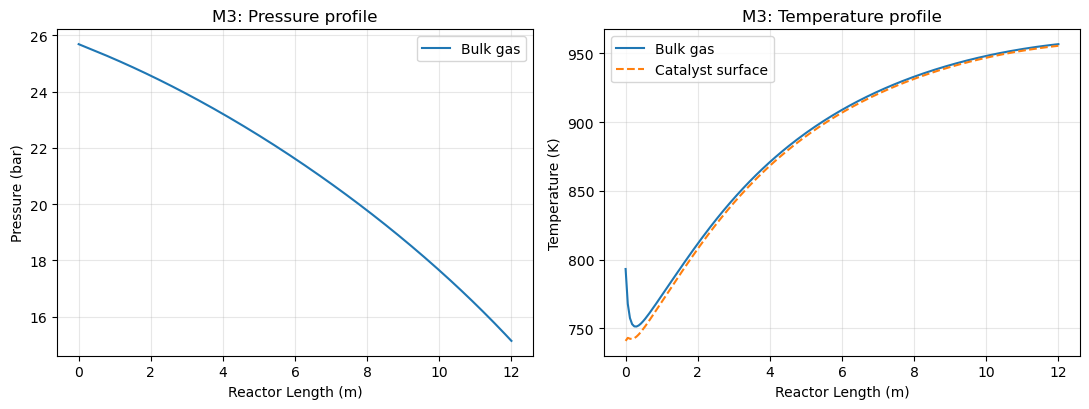

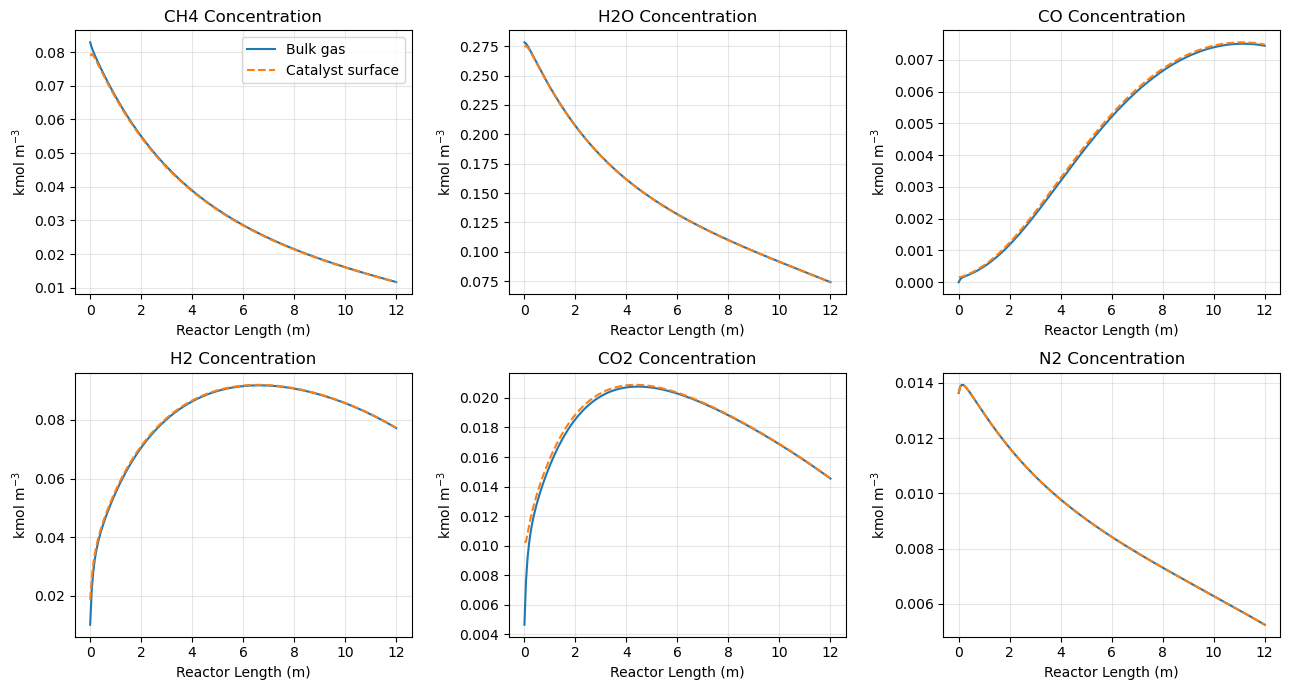

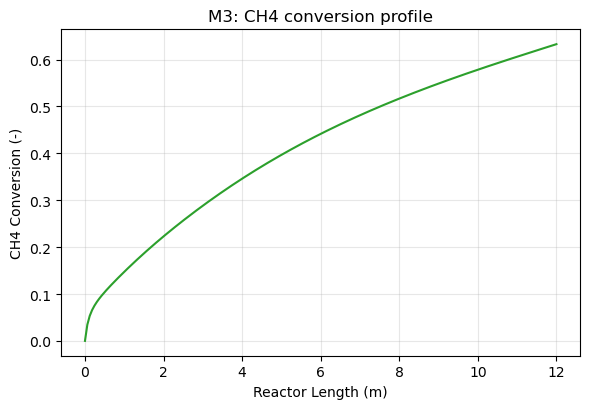

In [6]:

# ==============================================================================
# 5. INTEGRATE (single IVP pass, z = 0 .. L) AND POST-PROCESS
# ==============================================================================
def run_M3(eta=1.0):
    """eta: scalar or length-3 array of catalyst effectiveness factors (eta_j),
    matching the paper's use of a constant eta in M3 (Fig. 6/7 use eta=1)."""
    eta = np.atleast_1d(eta).astype(float)
    if eta.size == 1:
        eta = np.full(3, eta[0])

    y0 = np.concatenate([F_in, [T0, P0]])
    rhs = make_rhs(eta)
    z_eval = np.linspace(0, L, 200)

    sol = solve_ivp(rhs, (0, L), y0, method='LSODA', t_eval=z_eval,
                     rtol=1e-7, atol=1e-10)
    return sol


def postprocess(sol, eta=1.0):
    eta = np.atleast_1d(eta).astype(float)
    if eta.size == 1:
        eta = np.full(3, eta[0])

    z = sol.t
    F = sol.y[:n_sp, :]
    T = sol.y[n_sp, :]
    P = sol.y[n_sp + 1, :]

    Cs_hist = np.zeros((n_sp, len(z)))
    Ts_hist = np.zeros(len(z))
    cache = SurfaceCache(F_in / (Uz0 * Omega), T0)
    for k in range(len(z)):
        Fk, Tk, Pk = F[:, k], T[k], P[k]
        Mavg = np.sum(Fk * MW_arr) / np.sum(Fk)
        rho_g = Pk * Mavg / (Rbar * Tk)
        Uz = G0 / rho_g
        Ck = Fk / (Uz * Omega)
        yk = Fk / np.sum(Fk)
        mu_g = mixture_viscosity(Tk, yk)
        lam_g = mixture_thermal_conductivity(Tk, yk)
        Cp_i_kmol = cp_molar(Tk) * 1000.0
        Cp_g_mass = np.sum(Fk * Cp_i_kmol) / np.sum(Fk * MW_arr)
        Dim = diffusivity_mix(Tk, Pk, yk)
        Re = d_p * Uz * rho_g / mu_g
        Pr = Cp_g_mass * mu_g / lam_g
        Sc = mu_g / (rho_g * Dim)
        kgp = (Uz / eps_b) * (0.765 / Re**0.82 + 0.365 / Re**0.386) * Sc**(-2.0 / 3.0)
        hgp = (lam_g / d_p) * (2 + 1.1 * Pr**(1.0 / 3.0) * Re**0.6)
        Cs, Ts = solve_surface(Ck, Tk, kgp, hgp, eta, cache)
        Cs_hist[:, k] = Cs
        Ts_hist[k] = Ts

    X_CH4 = 1 - F[idx['CH4'], :] / F_in[idx['CH4']]     # Eq. (88)
    return z, F, T, P, Cs_hist, Ts_hist, X_CH4


if __name__ == '__main__':
    eta = 1.0    # matches the paper's Fig. 6/7 case (eta=1) for M1-vs-M3 comparison
    sol = run_M3(eta=eta)
    z, F, T, P, Cs, Ts, X_CH4 = postprocess(sol, eta=eta)

    print(f"Bed voidage eps_b = {eps_b:.4f}")
    print(f"Inlet superficial velocity Uz0 = {Uz0:.4f} m/s")
    print(f"Outlet CH4 conversion X_CH4(L) = {X_CH4[-1]:.4f}")
    print(f"Outlet pressure = {P[-1]:.3f} bar,  Outlet bulk T = {T[-1]:.2f} K, "
          f"Outlet surface Ts = {Ts[-1]:.2f} K")

    # ---- Fig. 6 equivalent: pressure & temperature (bulk gas vs catalyst surface) ----
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].plot(z, P, label='Bulk gas', color='tab:blue')
    axes[0].set_xlabel('Reactor Length (m)'); axes[0].set_ylabel('Pressure (bar)')
    axes[0].set_title('M3: Pressure profile'); axes[0].legend(); axes[0].grid(alpha=.3)

    axes[1].plot(z, T, label='Bulk gas', color='tab:blue')
    axes[1].plot(z, Ts, '--', label='Catalyst surface', color='tab:orange')
    axes[1].set_xlabel('Reactor Length (m)'); axes[1].set_ylabel('Temperature (K)')
    axes[1].set_title('M3: Temperature profile'); axes[1].legend(); axes[1].grid(alpha=.3)
    fig.tight_layout()
    #fig.savefig('/home/claude/M3_pressure_temperature.png', dpi=150)

    # ---- Fig. 7 equivalent: bulk vs surface concentration for each species ----
    Uz = np.array([G0 / (P[k] * (np.sum(F[:, k] * MW_arr) / np.sum(F[:, k])) / (Rbar * T[k]))
                   for k in range(len(z))])
    C_bulk = F / (Uz[np.newaxis, :] * Omega)

    fig2, axes2 = plt.subplots(2, 3, figsize=(13, 7))
    for i, s in enumerate(species):
        ax = axes2.flat[i]
        ax.plot(z, C_bulk[i, :], label='Bulk gas', color='tab:blue')
        ax.plot(z, Cs[i, :], '--', label='Catalyst surface', color='tab:orange')
        ax.set_title(f'{s} Concentration'); ax.set_xlabel('Reactor Length (m)')
        ax.set_ylabel('kmol m$^{-3}$'); ax.grid(alpha=.3)
        if i == 0:
            ax.legend()
    fig2.tight_layout()
    #fig2.savefig('/home/claude/M3_concentration_gas_vs_solid.png', dpi=150)

    # ---- CH4 conversion along reactor length, Eq. (88) ----
    fig3, ax3 = plt.subplots(figsize=(6, 4.2))
    ax3.plot(z, X_CH4, color='tab:green')
    ax3.set_xlabel('Reactor Length (m)'); ax3.set_ylabel('CH4 Conversion (-)')
    ax3.set_title('M3: CH4 conversion profile'); ax3.grid(alpha=.3)
    fig3.tight_layout()
    #fig3.savefig('/home/claude/M3_CH4_conversion.png', dpi=150)

    plt.show()